# Learning image watermarks: follow a signal into DCT space

An image watermark becomes easier to understand when you follow one payload bit from visible pixels into frequency space and back again. This notebook traces that path through a classical DCT construction, then asks what remains detectable after the image changes.

The examples reveal details that a before/after image hides: where the signal lives, how coefficient pairs represent bits, why repetition creates redundancy, and why crop-and-resize breaks synchronization. The image is synthetic and the detector is intentionally simple. It teaches the mechanism and its trade-offs; it does not represent the robustness of a production neural watermark.

## How to use this notebook

Run the cells from top to bottom. Begin with the complete pipeline, zoom into one 8×8 block, follow the coefficient edit, and only then compare transformations and strength settings.

By the end, you should be able to explain why:

- a payload bit can be stored as a relationship between two coefficients rather than visible text;
- repeating bits across blocks supports majority voting but reduces capacity;
- stronger coefficient separation can improve detection while increasing pixel error;
- JPEG and moderate noise differ fundamentally from transformations that change block alignment.

In [1]:
import io
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

try:
    import ipywidgets as widgets
    HAS_WIDGETS = True
except ImportError:
    widgets = None
    HAS_WIDGETS = False

RUN_INTERACTIVE = HAS_WIDGETS and os.environ.get('WATERMARKS_INTERACTIVE', '1') != '0'
print(f'ipywidgets available: {HAS_WIDGETS}')


ipywidgets available: True


## 1. Build a map of the pipeline

`RGB image → luminance → 8×8 block → DCT → change a coefficient pair → inverse DCT → watermarked image`

The DCT reorganizes an image block by spatial frequency. Low-frequency coefficients describe broad brightness and are easy to notice when changed. Very high frequencies are easier for resizing and JPEG quantization to discard. This demonstration therefore places evidence between those extremes, using coefficients `(2, 3)` and `(3, 2)`.

In [2]:
def make_test_image(size=256):
    yy, xx = np.mgrid[0:size, 0:size].astype(float)
    x, y = xx / size, yy / size
    image = np.zeros((size, size, 3), dtype=float)
    image[..., 0] = 55 + 90 * (1 - y) + 25 * x
    image[..., 1] = 105 + 70 * (1 - y)
    image[..., 2] = 185 + 45 * (1 - y)

    sun = (x - 0.72) ** 2 + (y - 0.28) ** 2 < 0.075 ** 2
    image[sun] = [255, 205, 75]
    ground = y > 0.72
    image[ground, 0] = 35 + 35 * x[ground]
    image[ground, 1] = 75 + 30 * x[ground]
    image[ground, 2] = 45 + 20 * x[ground]
    building = (x > 0.18) & (x < 0.48) & (y > 0.47) & (y < 0.73)
    image[building] = [50, 45, 55]
    windows = building & (((xx.astype(int) // 10) + (yy.astype(int) // 12)) % 2 == 0)
    image[windows] = [230, 185, 80]
    texture = 2.0 * np.sin(xx / 4.8) * np.cos(yy / 7.2)
    image += texture[..., None]
    return np.clip(image, 0, 255).astype(np.uint8)

def dct_matrix(n=8):
    i, k = np.arange(n)[:, None], np.arange(n)[None, :]
    basis = np.cos(np.pi / n * (i + 0.5) * k)
    basis[:, 0] /= np.sqrt(2)
    return np.sqrt(2 / n) * basis

DCT8 = dct_matrix()
COEFF_A = (2, 3)
COEFF_B = (3, 2)

def to_luminance(image):
    rgb = image.astype(float)
    return 0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]

def block_positions(height, width, block_size=8):
    return [(row, col)
            for row in range(0, height - block_size + 1, block_size)
            for col in range(0, width - block_size + 1, block_size)]

def payload_bits(text):
    raw = np.frombuffer(text.encode('utf-8'), dtype=np.uint8)
    return np.unpackbits(raw).astype(np.uint8)

def embed_dct(image, bits, strength=12.0):
    luminance = to_luminance(image)
    modified = luminance.copy()
    positions = block_positions(*luminance.shape)
    for index, (row, col) in enumerate(positions):
        block = luminance[row:row + 8, col:col + 8]
        coeff = DCT8 @ block @ DCT8.T
        difference = coeff[COEFF_A] - coeff[COEFF_B]
        target = float(strength) if bits[index % len(bits)] else -float(strength)
        if bits[index % len(bits)] and difference < target:
            adjustment = (target - difference) / 2
            coeff[COEFF_A] += adjustment
            coeff[COEFF_B] -= adjustment
        elif not bits[index % len(bits)] and difference > target:
            adjustment = (difference - target) / 2
            coeff[COEFF_A] -= adjustment
            coeff[COEFF_B] += adjustment
        modified[row:row + 8, col:col + 8] = DCT8.T @ coeff @ DCT8
    residual = modified - luminance
    return np.clip(image.astype(float) + residual[..., None], 0, 255).astype(np.uint8)

def detect_dct(image, payload_length):
    luminance = to_luminance(image)
    signs, margins = [], []
    for row, col in block_positions(*luminance.shape):
        block = luminance[row:row + 8, col:col + 8]
        coeff = DCT8 @ block @ DCT8.T
        difference = coeff[COEFF_A] - coeff[COEFF_B]
        signs.append(difference >= 0)
        margins.append(abs(difference))
    signs = np.asarray(signs, dtype=bool)
    decoded = np.asarray([np.mean(signs[index::payload_length]) >= 0.5
                         for index in range(payload_length)], dtype=np.uint8)
    return decoded, np.asarray(margins), signs

def bit_accuracy(actual, expected):
    return float(np.mean(np.asarray(actual) == np.asarray(expected)))

def jpeg_roundtrip(image, quality=55):
    buffer = io.BytesIO()
    Image.fromarray(image).save(buffer, format='JPEG', quality=int(quality))
    return np.asarray(Image.open(io.BytesIO(buffer.getvalue())).convert('RGB'))

def crop_resize(image, fraction=0.75):
    height, width = image.shape[:2]
    crop_height, crop_width = int(height * fraction), int(width * fraction)
    top, left = (height - crop_height) // 2, (width - crop_width) // 2
    cropped = Image.fromarray(image).crop((left, top, left + crop_width, top + crop_height))
    return np.asarray(cropped.resize((width, height), Image.Resampling.LANCZOS))

image = make_test_image()
payload = payload_bits('AI')
watermarked = embed_dct(image, payload, strength=12)
decoded, margins, block_signs = detect_dct(watermarked, len(payload))
print(f'Payload: AI = {len(payload)} bits; detector accuracy: {bit_accuracy(decoded, payload):.1%}')
print(f'Mean coefficient-pair margin: {margins.mean():.2f}')


Payload: AI = 16 bits; detector accuracy: 100.0%
Mean coefficient-pair margin: 13.61


## 2. Compare the visible image with its hidden residual

First compare the original and watermarked images at normal scale. They should look nearly identical. The residual panel then amplifies their numerical difference so the distributed edit becomes visible.

This separates two questions that should not be confused: whether the signal is perceptible to a viewer and whether a detector can measure it. The residual is spread across blocks rather than rendered as a visible logo.

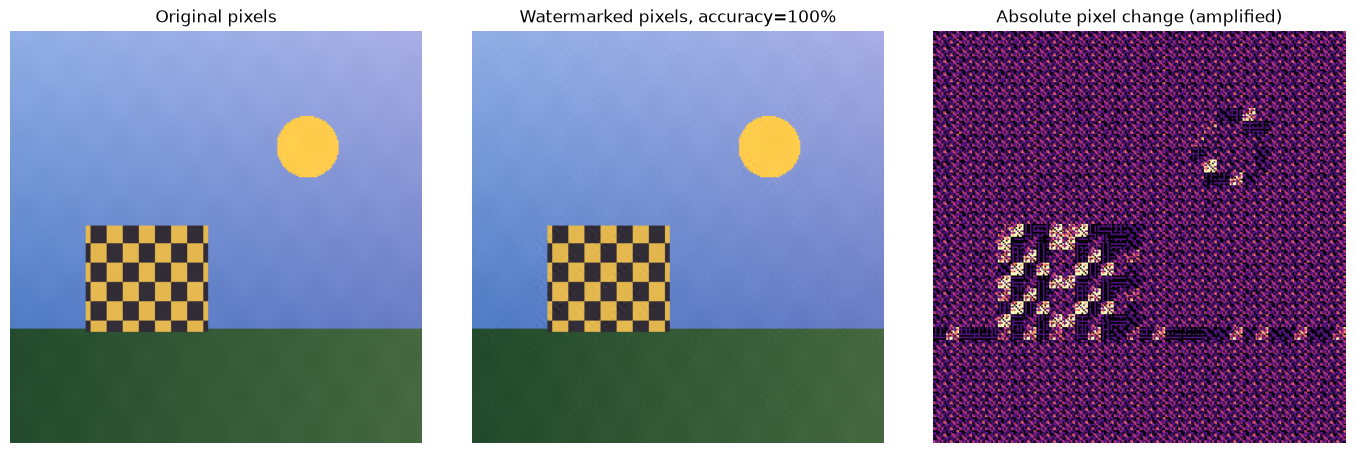

In [3]:
difference = np.abs(watermarked.astype(float) - image.astype(float)).mean(axis=2)
figure, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes[0].imshow(image)
axes[0].set_title('Original pixels')
axes[1].imshow(watermarked)
axes[1].set_title(f'Watermarked pixels, accuracy={bit_accuracy(decoded, payload):.0%}')
axes[2].imshow(difference, cmap='magma', vmin=0, vmax=max(1, np.percentile(difference, 99)))
axes[2].set_title('Absolute pixel change (amplified)')
for axis in axes:
    axis.axis('off')
plt.tight_layout()


## 3. Follow one block through every stage

Use the pipeline slider in order rather than jumping directly to the result. The selected 8×8 block is outlined in the full image, then shown as luminance values, DCT coefficients, edited coefficients and reconstructed pixels.

In the coefficient views, brighter cells have larger absolute values. The two cells marked `A` and `B` carry the bit through their relative difference. This is the smallest unit of the watermark used throughout the rest of the notebook.

In [4]:
STEP_NAMES = ['RGB pixels', 'luminance', 'selected 8x8 block', 'DCT coefficients', 'edited coefficients', 'inverse-DCT block', 'full watermarked image', 'JPEG round-trip']
BLOCK_ROW, BLOCK_COL = 64, 64

def block_coefficients(array):
    return DCT8 @ array[BLOCK_ROW:BLOCK_ROW + 8, BLOCK_COL:BLOCK_COL + 8] @ DCT8.T

def plot_pipeline_step(step=0, strength=12.0, jpeg_quality=55):
    current_watermarked = embed_dct(image, payload, strength=float(strength))
    compressed = jpeg_roundtrip(current_watermarked, quality=int(jpeg_quality))
    luminance = to_luminance(image)
    watermarked_luminance = to_luminance(current_watermarked)
    original_block = luminance[BLOCK_ROW:BLOCK_ROW + 8, BLOCK_COL:BLOCK_COL + 8]
    marked_block = watermarked_luminance[BLOCK_ROW:BLOCK_ROW + 8, BLOCK_COL:BLOCK_COL + 8]
    original_coeff = DCT8 @ original_block @ DCT8.T
    marked_coeff = DCT8 @ marked_block @ DCT8.T
    inverse_block = DCT8.T @ marked_coeff @ DCT8

    figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    selected = int(step)
    if selected in (0, 1, 2, 6, 7):
        pictures = [image, luminance, original_block, current_watermarked, compressed]
        picture = pictures[{0: 0, 1: 1, 2: 2, 6: 3, 7: 4}[selected]]
        axes[0].imshow(picture, cmap='gray' if picture.ndim == 2 else None)
        axes[0].set_title(STEP_NAMES[selected])
        if selected in (0, 1, 6, 7):
            axes[0].add_patch(Rectangle((BLOCK_COL, BLOCK_ROW), 8, 8, fill=False, edgecolor='yellow', linewidth=2))
    elif selected == 3:
        axes[0].imshow(np.log1p(np.abs(original_coeff)), cmap='viridis')
        axes[0].set_title('DCT coefficients: original')
    elif selected == 4:
        axes[0].imshow(np.log1p(np.abs(marked_coeff)), cmap='viridis')
        axes[0].set_title(f'DCT coefficients: edited, strength={float(strength):.1f}')
    elif selected == 5:
        axes[0].imshow(inverse_block, cmap='gray')
        axes[0].set_title('Inverse DCT: reconstructed block')
    axes[0].axis('off')

    detail = original_block if selected < 3 else (original_coeff if selected == 3 else marked_coeff)
    if selected == 5:
        detail = inverse_block - original_block
        detail_title = 'Pixel change in selected block'
    else:
        detail_title = 'Selected 8x8 luminance block' if selected < 3 else 'Coefficient magnitude (log scale)'
    axes[1].imshow(detail, cmap='coolwarm' if selected == 5 else 'viridis')
    axes[1].set_title(detail_title)
    axes[1].set_xticks(range(8))
    axes[1].set_yticks(range(8))
    for row, col, label in [(COEFF_A[0], COEFF_A[1], 'A'), (COEFF_B[0], COEFF_B[1], 'B')]:
        axes[1].text(col, row, label, ha='center', va='center', color='white', fontweight='bold')
    figure.suptitle(f'Step {selected + 1}/{len(STEP_NAMES)}: {STEP_NAMES[selected]}')
    plt.tight_layout()

if RUN_INTERACTIVE:
    widgets.interact(
        plot_pipeline_step,
        step=widgets.IntSlider(value=0, min=0, max=len(STEP_NAMES) - 1, step=1, description='pipeline step'),
        strength=widgets.FloatSlider(value=12, min=2, max=30, step=1, description='strength'),
        jpeg_quality=widgets.IntSlider(value=55, min=15, max=95, step=5, description='JPEG'),
    )
else:
    plot_pipeline_step()


interactive(children=(IntSlider(value=0, description='pipeline step', max=7), FloatSlider(value=12.0, descript…

## 4. See how one coefficient pair represents a bit

For a payload bit of `1`, the embedder makes coefficient A exceed B by at least the target margin. For `0`, it creates the opposite relationship. The detector later reads only the sign of that difference.

The scatter plot compares every block before and after embedding. Points that already satisfy the desired relationship move little; points on the wrong side must cross the decision boundary. This makes both the encoded bit and the role of `strength` visible.

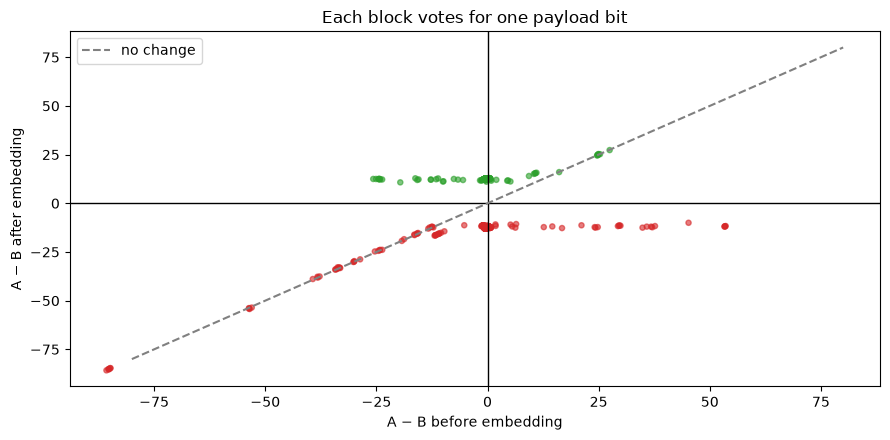

In [5]:
def coefficient_differences(current_image):
    luminance = to_luminance(current_image)
    differences = []
    for row, col in block_positions(*luminance.shape):
        coeff = DCT8 @ luminance[row:row + 8, col:col + 8] @ DCT8.T
        differences.append(coeff[COEFF_A] - coeff[COEFF_B])
    return np.asarray(differences)

original_differences = coefficient_differences(image)
marked_differences = coefficient_differences(watermarked)
block_bits = np.resize(payload, len(marked_differences))
figure, axis = plt.subplots(figsize=(9, 4.5))
axis.scatter(original_differences, marked_differences, c=np.where(block_bits, 'tab:green', 'tab:red'), alpha=0.6, s=14)
axis.axhline(0, color='black', linewidth=1)
axis.axvline(0, color='black', linewidth=1)
axis.plot([-80, 80], [-80, 80], color='gray', linestyle='--', label='no change')
axis.set_xlabel('A − B before embedding')
axis.set_ylabel('A − B after embedding')
axis.set_title('Each block votes for one payload bit')
axis.legend()
plt.tight_layout()


## 5. Test which transformations preserve the evidence

Now pass the same watermarked image through several channels. JPEG compression and additive noise change coefficient values but usually preserve the 8×8 block grid. A crop followed by resize changes which pixels land in each block.

The difference matters because this detector assumes the original alignment. When the grid moves, it combines the wrong block-level votes. Production systems need synchronization markers, multi-scale features or training that explicitly includes these transformations.

In [6]:
def show_transform(transform_name='JPEG', jpeg_quality=55, noise_sigma=2.5, crop_fraction=0.75):
    if transform_name == 'none':
        transformed = watermarked
    elif transform_name == 'JPEG':
        transformed = jpeg_roundtrip(watermarked, jpeg_quality)
    elif transform_name == 'noise':
        rng = np.random.default_rng(115)
        transformed = np.clip(watermarked.astype(float) + rng.normal(0, noise_sigma, watermarked.shape), 0, 255).astype(np.uint8)
    else:
        transformed = crop_resize(watermarked, crop_fraction)
    recovered, recovered_margins, _ = detect_dct(transformed, len(payload))
    figure, axes = plt.subplots(1, 3, figsize=(14, 4.2))
    axes[0].imshow(watermarked)
    axes[0].set_title('Before transform')
    axes[1].imshow(transformed)
    axes[1].set_title(f'After: {transform_name}')
    axes[2].bar(np.arange(len(payload)), recovered, color=['tab:green' if bit else 'tab:red' for bit in recovered])
    axes[2].set_ylim(-0.1, 1.1)
    axes[2].set_xlabel('payload bit index')
    axes[2].set_ylabel('decoded value')
    axes[2].set_title(f'accuracy={bit_accuracy(recovered, payload):.1%}, margin={recovered_margins.mean():.1f}')
    for axis in axes[:2]:
        axis.axis('off')
    plt.tight_layout()

if RUN_INTERACTIVE:
    widgets.interact(
        show_transform,
        transform_name=widgets.Dropdown(options=['none', 'JPEG', 'noise', 'crop and resize'], value='JPEG', description='transform'),
        jpeg_quality=widgets.IntSlider(value=55, min=15, max=95, step=5, description='JPEG'),
        noise_sigma=widgets.FloatSlider(value=2.5, min=0, max=10, step=0.5, description='noise'),
        crop_fraction=widgets.FloatSlider(value=0.75, min=0.5, max=0.95, step=0.05, description='crop'),
    )
else:
    show_transform()


interactive(children=(Dropdown(description='transform', index=1, options=('none', 'JPEG', 'noise', 'crop and r…

## 6. Measure robustness and distortion together

The final comparison varies both embedding strength and JPEG quality. Read the heatmap together with the distortion curve: detector accuracy without image quality is incomplete, and imperceptibility without post-transform detection is equally incomplete.

A meaningful robustness claim names the transformation, its severity, the detector threshold and the quality cost required to survive it.

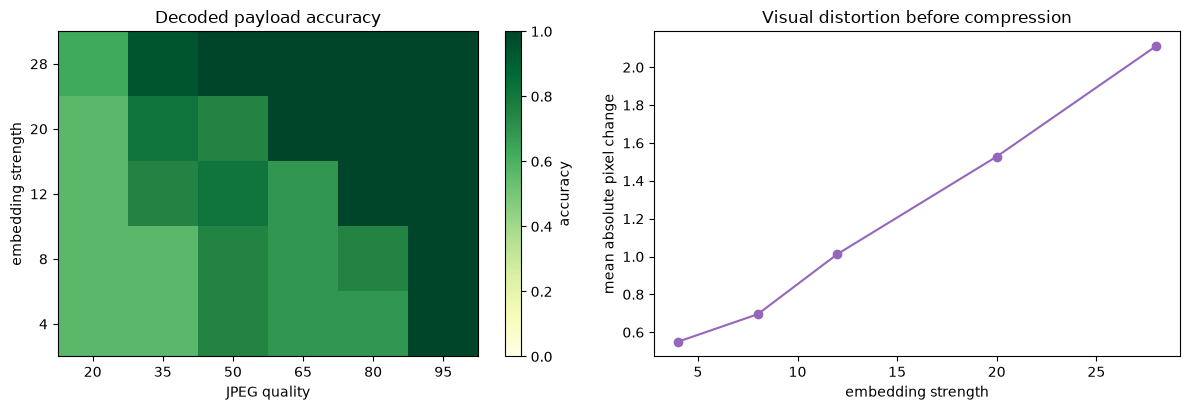

In [7]:
strengths = [4, 8, 12, 20, 28]
qualities = [20, 35, 50, 65, 80, 95]
accuracy_grid = np.zeros((len(strengths), len(qualities)))
distortion = []
for row, strength in enumerate(strengths):
    current = embed_dct(image, payload, strength=strength)
    distortion.append(np.abs(current.astype(float) - image.astype(float)).mean())
    for column, quality in enumerate(qualities):
        compressed = jpeg_roundtrip(current, quality)
        recovered, _, _ = detect_dct(compressed, len(payload))
        accuracy_grid[row, column] = bit_accuracy(recovered, payload)

figure, axes = plt.subplots(1, 2, figsize=(12, 4.2))
heatmap = axes[0].imshow(accuracy_grid, origin='lower', aspect='auto', vmin=0, vmax=1, cmap='YlGn')
axes[0].set_xticks(range(len(qualities)), qualities)
axes[0].set_yticks(range(len(strengths)), strengths)
axes[0].set_xlabel('JPEG quality')
axes[0].set_ylabel('embedding strength')
axes[0].set_title('Decoded payload accuracy')
figure.colorbar(heatmap, ax=axes[0], label='accuracy')
axes[1].plot(strengths, distortion, marker='o', color='tab:purple')
axes[1].set_xlabel('embedding strength')
axes[1].set_ylabel('mean absolute pixel change')
axes[1].set_title('Visual distortion before compression')
plt.tight_layout()


## What to carry forward

- A frequency-domain watermark is an engineered relationship among coefficients, not a visible overlay.
- Repetition turns noisy block-level decisions into a payload vote, at the cost of capacity.
- Robustness claims must name the transformation set: JPEG survival says little about crop synchronization.
- A production system needs synchronization, calibration, attack testing and a detector that is not exposed as a forgeable secret.